# BiLSTM Weekly Drought Classification - Kansas (Clean Baseline)

Notebook ini adalah versi rapi dari baseline Kansas dengan perbaikan utama:
- Dataset weekly terintegrasi: NASA POWER (daily -> weekly mean) + USDM weekly
- Patch leakage: fitur dibuat kausal (lag/rolling masa lalu), scaler fit hanya pada train
- Balancing hanya pada training sequences
- Hapus redundancy dari notebook awal

In [17]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [55]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.isotonic import IsotonicRegression

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Bidirectional,
    Dropout,
    Input,
    BatchNormalization,
    MultiHeadAttention,
    LayerNormalization,
    Add,
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


In [79]:
SEED = 42
DATA_PATH = 'Integrated_weekly_KAN.csv'
OUTPUT_FOLDER = 'output_weekly_kansas_clean_expC_recover'

# Weekly setup
SEQ_LENGTH = 52
BATCH_SIZE = 64
EPOCHS = 80

# Split setup: use time-aware split with distribution matching
SPLIT_MODE = 'auto_time_stratified'  # auto_time_stratified or fixed_dates
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MIN_WEEKS_PER_SPLIT = 52

# Used only when SPLIT_MODE='fixed_dates'
TRAIN_END_DATE = '2019-12-31'
VAL_START_DATE = '2020-01-01'
VAL_END_DATE = '2021-12-31'
TEST_START_DATE = '2022-01-01'

# Baseline metrics (from previous run) for comparison
BASELINE_MACRO_F1 = 0.59
BASELINE_D3_F1 = 0.27
BASELINE_D4_F1 = 0.00

# Boundary-focused experiment mode
EXPERIMENT_MODES = ['boundary_ce']

# Class-weight emphasis: strengthen boundary classes and preserve severe-class recall
CLASS_WEIGHT_BOOST = {
    0: 1.15,
    1: 1.65,
    2: 1.25,
    4: 3.00,
    5: 6.00,
}

# Boundary-aware loss controls
BOUNDARY_LOSS_LAMBDA = 0.35
LABEL_SMOOTHING = 0.02

# Calibration and robust thresholding
CALIBRATION_METHOD = 'isotonic'  # temperature or isotonic
ROLLING_FOLDS = 4
THRESH_OPT_PASSES = 3
THRESHOLD_GRIDS = {
    0: np.round(np.arange(0.70, 1.35, 0.05), 2),
    1: np.round(np.arange(0.75, 1.70, 0.05), 2),
    2: np.round(np.arange(0.75, 1.40, 0.05), 2),
    4: np.round(np.arange(0.60, 1.20, 0.05), 2),
    5: np.round(np.arange(0.05, 0.55, 0.05), 2),
}

# Regularization setup
L2_WEIGHT_DECAY = 1e-4
DROPOUT_LSTM_1 = 0.4
DROPOUT_LSTM_2 = 0.4
DROPOUT_DENSE = 0.3

# Training control
EARLY_STOPPING_PATIENCE = 4

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print('Config ready')
print(f'Data path: {DATA_PATH}')
print(f'Split mode: {SPLIT_MODE}')
print(f'Split ratios (train/val/test): {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}')
print(f'Min weeks per split: {MIN_WEEKS_PER_SPLIT}')
print(f'Experiment modes: {EXPERIMENT_MODES}')
print(f'Class weight boost: {CLASS_WEIGHT_BOOST}')
print(f'Boundary loss lambda: {BOUNDARY_LOSS_LAMBDA}')
print(f'Label smoothing: {LABEL_SMOOTHING}')
print(f'Calibration method: {CALIBRATION_METHOD}')
print(f'Rolling folds: {ROLLING_FOLDS}')
print(f'Threshold passes: {THRESH_OPT_PASSES}')
print(f'L2 weight decay: {L2_WEIGHT_DECAY}')
print(f'Dropout (LSTM1/LSTM2/Dense): {DROPOUT_LSTM_1}/{DROPOUT_LSTM_2}/{DROPOUT_DENSE}')
print(f'EarlyStopping patience: {EARLY_STOPPING_PATIENCE}')
print(f'Output folder: {OUTPUT_FOLDER}')

Config ready
Data path: Integrated_weekly_KAN.csv
Split mode: auto_time_stratified
Split ratios (train/val/test): 0.7/0.15/0.15
Min weeks per split: 52
Experiment modes: ['boundary_ce']
Class weight boost: {0: 1.15, 1: 1.65, 2: 1.25, 4: 3.0, 5: 6.0}
Boundary loss lambda: 0.35
Label smoothing: 0.02
Calibration method: isotonic
Rolling folds: 4
Threshold passes: 3
L2 weight decay: 0.0001
Dropout (LSTM1/LSTM2/Dense): 0.4/0.4/0.3
EarlyStopping patience: 4
Output folder: output_weekly_kansas_clean_expC_recover


In [57]:
df = pd.read_csv(DATA_PATH)
df['week_start'] = pd.to_datetime(df['week_start'])
df['ValidEnd'] = pd.to_datetime(df['ValidEnd'])
df = df.sort_values(['FIPS', 'week_start']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Unique counties: {df["FIPS"].nunique()}')
print(f'Date range: {df["week_start"].min().date()} to {df["week_start"].max().date()}')
display(df.head())

Shape: (77748, 20)
Unique counties: 93
Date range: 2009-12-29 to 2025-12-30


,week_start,ValidEnd,Year,Month,YearWeek,FIPS,County,State,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,WS2M,None,D0,D1,D2,D3,D4
0,2009-12-29,2010-01-04,2009,12,200953,20001,Allen County,KS,6.424625,0.281375,96.380500,85.468625,-9.298000,2.292375,100.0,0.0,0.0,0.0,0.0,0.0
1,2010-01-05,2010-01-11,2010,1,201001,20001,Allen County,KS,8.633143,0.228143,96.308000,80.965000,-9.317357,3.441643,100.0,0.0,0.0,0.0,0.0,0.0
2,2010-01-12,2010-01-18,2010,1,201002,20001,Allen County,KS,8.845143,0.023071,95.363714,85.271071,1.079714,2.279500,100.0,0.0,0.0,0.0,0.0,0.0
3,2010-01-19,2010-01-25,2010,1,201003,20001,Allen County,KS,7.583786,0.590286,93.982071,80.399571,2.468286,4.079071,100.0,0.0,0.0,0.0,0.0,0.0
4,2010-01-26,2010-02-01,2010,1,201004,20001,Allen County,KS,8.431714,0.984714,95.652714,76.353500,-2.827214,2.809286,100.0,0.0,0.0,0.0,0.0,0.0


In [58]:
def decumulate_drought(row):
    pmf_d4 = row['D4']
    pmf_d3 = max(0.0, row['D3'] - row['D4'])
    pmf_d2 = max(0.0, row['D2'] - row['D3'])
    pmf_d1 = max(0.0, row['D1'] - row['D2'])
    pmf_d0 = max(0.0, row['D0'] - row['D1'])
    pmf_none = max(0.0, row['None'])
    return pd.Series([pmf_none, pmf_d0, pmf_d1, pmf_d2, pmf_d3, pmf_d4])

pmf_cols = ['PMF_None', 'PMF_D0', 'PMF_D1', 'PMF_D2', 'PMF_D3', 'PMF_D4']
df[pmf_cols] = df.apply(decumulate_drought, axis=1)
df['PMF_Sum'] = df[pmf_cols].sum(axis=1)
df['Label'] = df[pmf_cols].idxmax(axis=1).apply(lambda x: pmf_cols.index(x))
label_map = {0: 'None', 1: 'D0', 2: 'D1', 3: 'D2', 4: 'D3', 5: 'D4'}

print('PMF sum stats:')
display(df['PMF_Sum'].describe())

class_dist = df['Label'].value_counts().sort_index()
print('Class distribution (full data):')
for idx, cnt in class_dist.items():
    print(f'  {label_map[idx]:>4s}: {cnt}')

PMF sum stats:


count    7.774800e+04
mean     1.000000e+02
std      1.358024e-15
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: PMF_Sum, dtype: float64

Class distribution (full data):
  None: 33904
    D0: 15656
    D1: 11960
    D2: 7932
    D3: 5167
    D4: 3129


In [59]:
base_weather = ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M']
df_fe = df.copy().sort_values(['FIPS', 'week_start']).reset_index(drop=True)

for lag in [1, 2, 4, 8]:
    df_fe[f'PREC_lag{lag}'] = df_fe.groupby('FIPS')['PRECTOTCORR'].shift(lag)
    df_fe[f'T2M_lag{lag}'] = df_fe.groupby('FIPS')['T2M'].shift(lag)
    df_fe[f'RH2M_lag{lag}'] = df_fe.groupby('FIPS')['RH2M'].shift(lag)

for window in [4, 12]:
    df_fe[f'PREC_roll{window}_mean'] = df_fe.groupby('FIPS')['PRECTOTCORR'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    df_fe[f'PREC_roll{window}_std'] = df_fe.groupby('FIPS')['PRECTOTCORR'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0.0))
    df_fe[f'T2M_roll{window}_mean'] = df_fe.groupby('FIPS')['T2M'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())

iso_week = df_fe['week_start'].dt.isocalendar().week.astype(int)
df_fe['week_sin'] = np.sin(2 * np.pi * iso_week / 52.0)
df_fe['week_cos'] = np.cos(2 * np.pi * iso_week / 52.0)

for col in ['D1', 'D2', 'D3', 'D4']:
    df_fe[f'{col}_lag1'] = df_fe.groupby('FIPS')[col].shift(1)

df_fe['drought_carryover_lag1'] = df_fe['D1_lag1'] + 0.5 * df_fe['D2_lag1']
df_fe['severe_carryover_lag1'] = df_fe['D3_lag1'] + df_fe['D4_lag1']
df_fe['heat_dry_stress'] = df_fe['T2M'] * (1.0 - df_fe['RH2M'] / 100.0)

feature_cols = [
    'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M',
    'PREC_lag1', 'PREC_lag2', 'PREC_lag4', 'PREC_lag8',
    'T2M_lag1', 'T2M_lag2', 'T2M_lag4', 'T2M_lag8',
    'RH2M_lag1', 'RH2M_lag2', 'RH2M_lag4', 'RH2M_lag8',
    'PREC_roll4_mean', 'PREC_roll4_std', 'PREC_roll12_mean', 'PREC_roll12_std',
    'T2M_roll4_mean', 'T2M_roll12_mean',
    'week_sin', 'week_cos',
    'drought_carryover_lag1', 'severe_carryover_lag1', 'heat_dry_stress'
]

before_drop = len(df_fe)
df_fe = df_fe.dropna(subset=feature_cols + ['Label']).reset_index(drop=True)
print(f'Rows before dropna: {before_drop:,}')
print(f'Rows after dropna:  {len(df_fe):,}')
print(f'Feature count: {len(feature_cols)}')

Rows before dropna: 77,748
Rows after dropna:  77,004
Feature count: 29


In [60]:
def normalized_counts(y, n_classes=6):
    counts = np.bincount(y.astype(int), minlength=n_classes).astype(np.float64)
    total = counts.sum()
    return counts / total if total > 0 else np.zeros(n_classes, dtype=np.float64)


def js_divergence(p, q, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    q = np.clip(q, eps, 1.0)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return 0.5 * (kl_pm + kl_qm)


def choose_time_stratified_cutoffs(df_input, label_col='Label', week_col='week_start'):
    weeks = np.array(sorted(df_input[week_col].unique()))
    n_weeks = len(weeks)
    if n_weeks < 3 * MIN_WEEKS_PER_SPLIT:
        raise ValueError(f'Not enough weeks ({n_weeks}) for requested MIN_WEEKS_PER_SPLIT={MIN_WEEKS_PER_SPLIT}.')

    train_idx_min = MIN_WEEKS_PER_SPLIT
    train_idx_max = n_weeks - 2 * MIN_WEEKS_PER_SPLIT

    best = None

    for train_end_idx in range(train_idx_min, train_idx_max + 1):
        val_end_idx_min = train_end_idx + MIN_WEEKS_PER_SPLIT
        val_end_idx_max = n_weeks - MIN_WEEKS_PER_SPLIT
        for val_end_idx in range(val_end_idx_min, val_end_idx_max + 1):
            train_end = weeks[train_end_idx - 1]
            val_end = weeks[val_end_idx - 1]

            train_mask = df_input[week_col] <= train_end
            val_mask = (df_input[week_col] > train_end) & (df_input[week_col] <= val_end)
            test_mask = df_input[week_col] > val_end

            y_train = df_input.loc[train_mask, label_col].values
            y_val = df_input.loc[val_mask, label_col].values
            y_test = df_input.loc[test_mask, label_col].values

            if len(y_train) == 0 or len(y_val) == 0 or len(y_test) == 0:
                continue

            p_train = normalized_counts(y_train)
            p_val = normalized_counts(y_val)
            p_test = normalized_counts(y_test)

            js_tv = js_divergence(p_train, p_val)
            js_tt = js_divergence(p_train, p_test)

            missing_penalty = 0.0
            for cls in range(6):
                if p_train[cls] > 0.01 and (p_val[cls] == 0 or p_test[cls] == 0):
                    missing_penalty += 1.0

            ratio_penalty = (
                abs(train_end_idx / n_weeks - TRAIN_RATIO)
                + abs((val_end_idx - train_end_idx) / n_weeks - VAL_RATIO)
                + abs((n_weeks - val_end_idx) / n_weeks - TEST_RATIO)
            )

            score = (1.0 * js_tv) + (0.75 * js_tt) + (1.5 * missing_penalty) + (0.25 * ratio_penalty)

            if best is None or score < best['score']:
                best = {
                    'score': score,
                    'train_end': train_end,
                    'val_end': val_end,
                    'train_weeks': train_end_idx,
                    'val_weeks': val_end_idx - train_end_idx,
                    'test_weeks': n_weeks - val_end_idx,
                    'js_train_val': js_tv,
                    'js_train_test': js_tt,
                }

    if best is None:
        raise RuntimeError('Unable to find valid split cutoffs.')

    return best


if SPLIT_MODE == 'fixed_dates':
    train_df = df_fe[df_fe['week_start'] <= TRAIN_END_DATE].copy()
    val_df = df_fe[(df_fe['week_start'] >= VAL_START_DATE) & (df_fe['week_start'] <= VAL_END_DATE)].copy()
    test_df = df_fe[df_fe['week_start'] >= TEST_START_DATE].copy()
    split_meta = {
        'mode': 'fixed_dates',
        'train_end': pd.to_datetime(TRAIN_END_DATE),
        'val_end': pd.to_datetime(VAL_END_DATE),
        'js_train_val': np.nan,
        'js_train_test': np.nan,
    }
else:
    best_split = choose_time_stratified_cutoffs(df_fe, label_col='Label', week_col='week_start')
    train_end = best_split['train_end']
    val_end = best_split['val_end']

    train_df = df_fe[df_fe['week_start'] <= train_end].copy()
    val_df = df_fe[(df_fe['week_start'] > train_end) & (df_fe['week_start'] <= val_end)].copy()
    test_df = df_fe[df_fe['week_start'] > val_end].copy()

    split_meta = {
        'mode': SPLIT_MODE,
        'train_end': train_end,
        'val_end': val_end,
        'js_train_val': best_split['js_train_val'],
        'js_train_test': best_split['js_train_test'],
        'train_weeks': best_split['train_weeks'],
        'val_weeks': best_split['val_weeks'],
        'test_weeks': best_split['test_weeks'],
    }

print(f"Train rows: {len(train_df):,}")
print(f"Val rows:   {len(val_df):,}")
print(f"Test rows:  {len(test_df):,}")
print(f"Split mode: {split_meta['mode']}")
print(f"Train end:  {pd.to_datetime(split_meta['train_end']).date()}")
print(f"Val end:    {pd.to_datetime(split_meta['val_end']).date()}")
if not np.isnan(split_meta['js_train_val']):
    print(f"JS(train,val):  {split_meta['js_train_val']:.4f}")
    print(f"JS(train,test): {split_meta['js_train_test']:.4f}")

for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split_df['Label'].value_counts().sort_index()
    total = len(split_df)
    print(f"\n{split_name} class distribution:")
    for idx in range(6):
        count = int(dist.get(idx, 0))
        ratio = (count / total) if total else 0.0
        print(f"  {label_map[idx]:>4s}: {count:6d} ({ratio:.2%})")

# Hard check against accidental temporal leakage
if train_df['week_start'].max() >= val_df['week_start'].min():
    print('WARNING: train and val ranges overlap.')
if val_df['week_start'].max() >= test_df['week_start'].min():
    print('WARNING: val and test ranges overlap.')

Train rows: 53,010
Val rows:   10,323
Test rows:  13,671
Split mode: auto_time_stratified
Train end:  2021-01-19
Val end:    2023-03-07
JS(train,val):  0.0087
JS(train,test): 0.0183

Train class distribution:
  None:  24898 (46.97%)
    D0:  10252 (19.34%)
    D1:   7112 (13.42%)
    D2:   5423 (10.23%)
    D3:   3525 (6.65%)
    D4:   1800 (3.40%)

Val class distribution:
  None:   3975 (38.51%)
    D0:   1892 (18.33%)
    D1:   1550 (15.02%)
    D2:   1114 (10.79%)
    D3:    936 (9.07%)
    D4:    856 (8.29%)

Test class distribution:
  None:   4287 (31.36%)
    D0:   3512 (25.69%)
    D1:   3298 (24.12%)
    D2:   1395 (10.20%)
    D3:    706 (5.16%)
    D4:    473 (3.46%)


In [61]:
scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])

for split_df in [train_df, val_df, test_df]:
    split_df.loc[:, feature_cols] = scaler.transform(split_df[feature_cols])

print('Scaling done using train-only fit.')

Scaling done using train-only fit.


In [62]:
def create_all_sequences(df_input, feature_columns, label_col, seq_length=52, id_col='FIPS'):
    X, y, y_date = [], [], []
    for _, group in df_input.groupby(id_col):
        group = group.sort_values('week_start')
        feats = group[feature_columns].values
        labels = group[label_col].values
        dates = group['week_start'].values
        if len(group) < seq_length:
            continue
        for i in range(len(group) - seq_length + 1):
            end_idx = i + seq_length - 1
            X.append(feats[i:i + seq_length])
            y.append(labels[end_idx])
            y_date.append(dates[end_idx])
    return np.array(X), np.array(y), np.array(y_date)


# Build continuous per-county timeline after train-only scaling.
df_scaled = pd.concat([
    train_df[['FIPS', 'week_start', 'Label'] + feature_cols],
    val_df[['FIPS', 'week_start', 'Label'] + feature_cols],
    test_df[['FIPS', 'week_start', 'Label'] + feature_cols],
], axis=0).sort_values(['FIPS', 'week_start']).reset_index(drop=True)

X_all_seq, y_all_seq, y_all_date = create_all_sequences(df_scaled, feature_cols, 'Label', SEQ_LENGTH)

train_cut = pd.to_datetime(split_meta['train_end']).to_datetime64()
val_cut = pd.to_datetime(split_meta['val_end']).to_datetime64()

train_mask = y_all_date <= train_cut
val_mask = (y_all_date > train_cut) & (y_all_date <= val_cut)
test_mask = y_all_date > val_cut

X_train_seq, y_train_seq, y_train_date = X_all_seq[train_mask], y_all_seq[train_mask], y_all_date[train_mask]
X_val_seq, y_val_seq, y_val_date = X_all_seq[val_mask], y_all_seq[val_mask], y_all_date[val_mask]
X_test_seq, y_test, y_test_date = X_all_seq[test_mask], y_all_seq[test_mask], y_all_date[test_mask]

print(f'X_train_seq: {X_train_seq.shape}')
print(f'X_val_seq:   {X_val_seq.shape}')
print(f'X_test_seq:  {X_test_seq.shape}')
print(f'Train distribution: {Counter(y_train_seq)}')
print(f'Val distribution:   {Counter(y_val_seq)}')
print(f'Test distribution:  {Counter(y_test)}')
print(f'Val period for threshold CV: {pd.to_datetime(y_val_date.min()).date()} to {pd.to_datetime(y_val_date.max()).date()}')

split_dates = {
    'train_max': train_df['week_start'].max(),
    'val_min': val_df['week_start'].min(),
    'val_max': val_df['week_start'].max(),
    'test_min': test_df['week_start'].min(),
}
print('\nSplit boundary check:')
print(split_dates)
if split_dates['train_max'] >= split_dates['val_min']:
    print('WARNING: train and val date ranges overlap.')
if split_dates['val_max'] >= split_dates['test_min']:
    print('WARNING: val and test date ranges overlap.')

X_train_seq: (48267, 52, 29)
X_val_seq:   (10323, 52, 29)
X_test_seq:  (13671, 52, 29)
Train distribution: Counter({np.int64(0): 21177, np.int64(1): 9563, np.int64(2): 6797, np.int64(3): 5405, np.int64(4): 3525, np.int64(5): 1800})
Val distribution:   Counter({np.int64(0): 3975, np.int64(1): 1892, np.int64(2): 1550, np.int64(3): 1114, np.int64(4): 936, np.int64(5): 856})
Test distribution:  Counter({np.int64(0): 4287, np.int64(1): 3512, np.int64(2): 3298, np.int64(3): 1395, np.int64(4): 706, np.int64(5): 473})
Val period for threshold CV: 2021-01-26 to 2023-03-07

Split boundary check:
{'train_max': Timestamp('2021-01-19 00:00:00'), 'val_min': Timestamp('2021-01-26 00:00:00'), 'val_max': Timestamp('2023-03-07 00:00:00'), 'test_min': Timestamp('2023-03-14 00:00:00')}


In [80]:
# Preserve original sequence distribution (no ROS / synthetic sampling)
n_samples, n_steps, n_features = X_train_seq.shape
X_train_model = X_train_seq
y_train_model = y_train_seq

print('Oversampling disabled. Using original training distribution.')
print(f'Train shape: {X_train_model.shape}')
print(f'Train distribution: {Counter(y_train_model)}')

classes = np.arange(6)
base_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_model.astype(int),
)
base_class_weight_dict = {int(c): float(w) for c, w in zip(classes, base_weights_arr)}

boosted_class_weight_dict = base_class_weight_dict.copy()
for cls, mult in CLASS_WEIGHT_BOOST.items():
    boosted_class_weight_dict[int(cls)] = boosted_class_weight_dict[int(cls)] * float(mult)

print('Base class weights:', base_class_weight_dict)
print('Boosted class weights:', boosted_class_weight_dict)

Oversampling disabled. Using original training distribution.
Train shape: (48267, 52, 29)
Train distribution: Counter({np.int64(0): 21177, np.int64(1): 9563, np.int64(2): 6797, np.int64(3): 5405, np.int64(4): 3525, np.int64(5): 1800})
Base class weights: {0: 0.37986966992491855, 1: 0.8412109170762313, 2: 1.18353685449463, 3: 1.4883441258094356, 4: 2.282127659574468, 5: 4.469166666666666}
Boosted class weights: {0: 0.4368501204136563, 1: 1.3879980131757816, 2: 1.4794210681182876, 3: 1.4883441258094356, 4: 6.846382978723404, 5: 26.814999999999998}


In [81]:
num_classes = 6
y_train_enc = to_categorical(y_train_model, num_classes=num_classes)
y_val_enc = to_categorical(y_val_seq, num_classes=num_classes)
y_test_enc = to_categorical(y_test, num_classes=num_classes)


def build_attention_model(seq_length, n_features, n_classes):
    reg = l2(L2_WEIGHT_DECAY)

    inp = Input(shape=(seq_length, n_features))
    x = Bidirectional(
        LSTM(128, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg)
    )(inp)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT_LSTM_1)(x)

    attn = MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.10)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    x = Bidirectional(
        LSTM(64, kernel_regularizer=reg, recurrent_regularizer=reg)
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT_LSTM_2)(x)

    x = Dense(96, activation='relu', kernel_regularizer=reg)(x)
    x = Dropout(DROPOUT_DENSE)(x)
    out = Dense(n_classes, activation='softmax', kernel_regularizer=reg)(x)

    model = Model(inputs=inp, outputs=out)
    return model


def make_boundary_cost_matrix(n_classes=6):
    cm = np.zeros((n_classes, n_classes), dtype=np.float32)

    # Base penalty by label distance.
    for i in range(n_classes):
        for j in range(n_classes):
            if i == j:
                continue
            cm[i, j] = 0.05 * abs(i - j)

    # Extra penalties on dominant confusion boundaries.
    cm[0, 1] = 1.6
    cm[1, 0] = 1.4
    cm[1, 2] = 1.0
    cm[2, 1] = 0.9
    cm[0, 2] = 0.7
    cm[2, 0] = 0.7
    return cm


def boundary_aware_cce(cost_matrix, loss_lambda=0.20, label_smoothing=0.015):
    cost_t = tf.constant(cost_matrix, dtype=tf.float32)
    cce = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=label_smoothing,
        reduction=tf.keras.losses.Reduction.NONE,
    )

    def loss_fn(y_true, y_pred):
        base = cce(y_true, y_pred)
        expected_cost = tf.reduce_sum(tf.matmul(y_true, cost_t) * y_pred, axis=-1)
        return base + float(loss_lambda) * expected_cost

    return loss_fn


def make_callbacks(tag):
    return [
        EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{OUTPUT_FOLDER}/best_model_{tag}.keras', monitor='val_loss', save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ]


def safe_normalize_probs(prob):
    prob = np.clip(prob, 1e-8, None)
    prob = prob / prob.sum(axis=1, keepdims=True)
    return prob


def fit_isotonic_calibrators(prob, y_true, n_classes=6):
    calibrators = []
    for cls_idx in range(n_classes):
        y_bin = (y_true == cls_idx).astype(int)
        if y_bin.min() == y_bin.max():
            calibrators.append(None)
            continue

        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(prob[:, cls_idx], y_bin)
        calibrators.append(iso)

    return calibrators


def apply_isotonic_calibrators(prob, calibrators):
    out = np.zeros_like(prob, dtype=np.float64)
    for cls_idx, cal in enumerate(calibrators):
        if cal is None:
            out[:, cls_idx] = prob[:, cls_idx]
        else:
            out[:, cls_idx] = cal.transform(prob[:, cls_idx])
    return safe_normalize_probs(out)


def fit_temperature_params(prob, y_true, n_classes=6, temp_grid=None):
    if temp_grid is None:
        temp_grid = np.round(np.arange(0.70, 2.05, 0.05), 2)

    temps = np.ones(n_classes, dtype=np.float64)
    p = np.clip(prob, 1e-6, 1.0 - 1e-6)
    logits = np.log(p / (1.0 - p))

    for cls_idx in range(n_classes):
        y_bin = (y_true == cls_idx).astype(np.float64)
        best_t = 1.0
        best_brier = np.inf

        for t in temp_grid:
            p_t = 1.0 / (1.0 + np.exp(-logits[:, cls_idx] / float(t)))
            brier = np.mean((p_t - y_bin) ** 2)
            if brier < best_brier:
                best_brier = brier
                best_t = float(t)

        temps[cls_idx] = best_t

    return temps


def apply_temperature_params(prob, temps):
    p = np.clip(prob, 1e-6, 1.0 - 1e-6)
    logits = np.log(p / (1.0 - p))
    scaled = np.zeros_like(p)

    for cls_idx in range(p.shape[1]):
        t = max(float(temps[cls_idx]), 1e-6)
        scaled[:, cls_idx] = 1.0 / (1.0 + np.exp(-logits[:, cls_idx] / t))

    return safe_normalize_probs(scaled)


def fit_calibrator(prob, y_true, method='temperature', n_classes=6):
    if method == 'isotonic':
        return {'method': 'isotonic', 'params': fit_isotonic_calibrators(prob, y_true, n_classes=n_classes)}
    if method == 'temperature':
        return {'method': 'temperature', 'params': fit_temperature_params(prob, y_true, n_classes=n_classes)}
    raise ValueError(f'Unknown calibration method: {method}')


def apply_calibrator(prob, calibrator):
    if calibrator['method'] == 'isotonic':
        return apply_isotonic_calibrators(prob, calibrator['params'])
    if calibrator['method'] == 'temperature':
        return apply_temperature_params(prob, calibrator['params'])
    raise ValueError(f"Unknown calibrator method: {calibrator['method']}")


def build_rolling_origin_folds(date_array, n_folds=4, min_train_frac=0.35):
    dates = pd.Series(pd.to_datetime(date_array)).reset_index(drop=True)
    unique_dates = np.array(sorted(dates.unique()))

    if len(unique_dates) < 8:
        return []

    start_idx = max(int(round(len(unique_dates) * min_train_frac)), 1)
    remaining = len(unique_dates) - start_idx
    if remaining <= 1:
        return []

    k = min(int(n_folds), remaining)
    window = max(1, remaining // k)

    folds = []
    for fold_idx in range(k):
        eval_start_idx = start_idx + fold_idx * window
        eval_end_idx = start_idx + (fold_idx + 1) * window if fold_idx < k - 1 else len(unique_dates)

        if eval_start_idx >= len(unique_dates):
            continue

        eval_start_date = unique_dates[eval_start_idx]
        eval_end_date = unique_dates[max(eval_start_idx, eval_end_idx - 1)]

        train_mask = (dates < eval_start_date).values
        eval_mask = ((dates >= eval_start_date) & (dates <= eval_end_date)).values

        if train_mask.sum() == 0 or eval_mask.sum() == 0:
            continue

        folds.append({
            'train_mask': train_mask,
            'eval_mask': eval_mask,
            'eval_start': pd.to_datetime(eval_start_date),
            'eval_end': pd.to_datetime(eval_end_date),
        })

    return folds


def rolling_calibration_oof(prob, y_true, date_array, method='temperature', n_classes=6, n_folds=4):
    folds = build_rolling_origin_folds(date_array, n_folds=n_folds)
    oof_cal = np.full(prob.shape, np.nan, dtype=np.float64)
    used_mask = np.zeros(len(y_true), dtype=bool)

    for fold in folds:
        tr = fold['train_mask']
        ev = fold['eval_mask']
        cal = fit_calibrator(prob[tr], y_true[tr], method=method, n_classes=n_classes)
        oof_cal[ev] = apply_calibrator(prob[ev], cal)
        used_mask[ev] = True

    return oof_cal, used_mask, folds


def apply_thresholds_multiclass(prob, thresholds):
    adjusted = prob.copy()
    for cls_idx, thr in thresholds.items():
        adjusted[:, int(cls_idx)] = adjusted[:, int(cls_idx)] / max(float(thr), 1e-6)
    return np.argmax(adjusted, axis=1)


def boundary_objective(y_true, y_pred):
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_per = f1_score(y_true, y_pred, labels=list(range(6)), average=None, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))
    den_01 = max(cm[0].sum() + cm[1].sum(), 1)
    den_12 = max(cm[1].sum() + cm[2].sum(), 1)
    pair_err_01 = (cm[0, 1] + cm[1, 0]) / den_01
    pair_err_12 = (cm[1, 2] + cm[2, 1]) / den_12

    objective = macro + 0.08 * f1_per[4] + 0.10 * f1_per[5] - 0.30 * pair_err_01 - 0.15 * pair_err_12

    return {
        'objective': float(objective),
        'macro_f1': float(macro),
        'f1_per': f1_per,
        'pair_err_01': float(pair_err_01),
        'pair_err_12': float(pair_err_12),
    }


def tune_thresholds_rolling(y_true, prob_cal, folds, threshold_grids, n_passes=3):
    thresholds = {int(cls): 1.0 for cls in threshold_grids.keys()}

    if len(folds) == 0:
        return thresholds, pd.DataFrame()

    for _ in range(int(n_passes)):
        for cls_idx, grid in threshold_grids.items():
            best_thr = thresholds[int(cls_idx)]
            best_score = -np.inf

            for thr in grid:
                trial = thresholds.copy()
                trial[int(cls_idx)] = float(thr)

                fold_scores = []
                for fold in folds:
                    ev = fold['eval_mask']
                    y_hat = apply_thresholds_multiclass(prob_cal[ev], trial)
                    fold_scores.append(boundary_objective(y_true[ev], y_hat)['objective'])

                mean_score = float(np.mean(fold_scores))
                if mean_score > best_score:
                    best_score = mean_score
                    best_thr = float(thr)

            thresholds[int(cls_idx)] = best_thr

    diag_rows = []
    for fold_id, fold in enumerate(folds, start=1):
        ev = fold['eval_mask']
        y_hat = apply_thresholds_multiclass(prob_cal[ev], thresholds)
        obj = boundary_objective(y_true[ev], y_hat)
        diag_rows.append({
            'fold': fold_id,
            'eval_start': fold['eval_start'].date(),
            'eval_end': fold['eval_end'].date(),
            'macro_f1': obj['macro_f1'],
            'pair_err_01': obj['pair_err_01'],
            'pair_err_12': obj['pair_err_12'],
            'objective': obj['objective'],
        })

    return thresholds, pd.DataFrame(diag_rows)


def top_confusion_pairs(y_true, y_pred, top_k=6):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))
    pairs = []
    for i in range(6):
        for j in range(6):
            if i == j:
                continue
            pairs.append((int(i), int(j), int(cm[i, j])))
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    return pairs[:top_k], cm


print('Boundary-aware model, calibration, and rolling-threshold utilities ready.')

Boundary-aware model, calibration, and rolling-threshold utilities ready.


In [ ]:
def summarize_predictions(y_true, y_pred):
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    acc = accuracy_score(y_true, y_pred)

    pr, rc, f1c, sup = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(6)),
        zero_division=0,
    )

    class_table = pd.DataFrame({
        'class_idx': list(range(6)),
        'class_name': [label_map[i] for i in range(6)],
        'precision': pr,
        'recall': rc,
        'f1': f1c,
        'support': sup,
    })

    cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))

    return {
        'macro': float(macro),
        'weighted': float(weighted),
        'accuracy': float(acc),
        'class_table': class_table,
        'cm': cm,
    }


def run_boundary_experiment():
    print('\n' + '=' * 88)
    print('Training mode: boundary_ce')
    print('Setup: attention BiLSTM + boundary-aware CE + class-wise calibration + rolling threshold CV')
    print('=' * 88)

    model_local = build_attention_model(SEQ_LENGTH, n_features, num_classes)
    boundary_cost = make_boundary_cost_matrix(num_classes)
    loss_fn = boundary_aware_cce(
        boundary_cost,
        loss_lambda=BOUNDARY_LOSS_LAMBDA,
        label_smoothing=LABEL_SMOOTHING,
    )

    model_local.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss_fn,
        metrics=['accuracy'],
    )

    history_local = model_local.fit(
        X_train_model,
        y_train_enc,
        validation_data=(X_val_seq, y_val_enc),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks('boundary_ce'),
        class_weight=boosted_class_weight_dict,
        shuffle=False,
        verbose=1,
    )

    y_val_prob_raw = model_local.predict(X_val_seq, verbose=0)
    y_test_prob_raw = model_local.predict(X_test_seq, verbose=0)

    y_val_pred_raw = np.argmax(y_val_prob_raw, axis=1)
    y_test_pred_raw = np.argmax(y_test_prob_raw, axis=1)

    val_before_obj = boundary_objective(y_val_seq, y_val_pred_raw)
    before_summary = summarize_predictions(y_test, y_test_pred_raw)
    dominant_before, cm_before = top_confusion_pairs(y_test, y_test_pred_raw, top_k=8)

    oof_val_cal, oof_mask, rolling_folds = rolling_calibration_oof(
        y_val_prob_raw,
        y_val_seq,
        y_val_date,
        method=CALIBRATION_METHOD,
        n_classes=num_classes,
        n_folds=ROLLING_FOLDS,
    )
    print(f'Calibration method: {CALIBRATION_METHOD}')
    print(f'Calibration OOF coverage: {oof_mask.mean():.2%}')

    if len(rolling_folds) == 0:
        print('WARNING: rolling folds unavailable, using default thresholds.')
        threshold_map = {int(k): 1.0 for k in THRESHOLD_GRIDS.keys()}
        cv_diag = pd.DataFrame()
    else:
        threshold_map, cv_diag = tune_thresholds_rolling(
            y_true=y_val_seq,
            prob_cal=oof_val_cal,
            folds=rolling_folds,
            threshold_grids=THRESHOLD_GRIDS,
            n_passes=THRESH_OPT_PASSES,
        )

    full_cal = fit_calibrator(
        y_val_prob_raw,
        y_val_seq,
        method=CALIBRATION_METHOD,
        n_classes=num_classes,
    )
    y_val_prob_cal = apply_calibrator(y_val_prob_raw, full_cal)
    y_test_prob_cal = apply_calibrator(y_test_prob_raw, full_cal)

    y_val_pred_cal = apply_thresholds_multiclass(y_val_prob_cal, threshold_map)
    y_test_pred_cal = apply_thresholds_multiclass(y_test_prob_cal, threshold_map)

    val_after_obj = boundary_objective(y_val_seq, y_val_pred_cal)
    cal_summary = summarize_predictions(y_test, y_test_pred_cal)
    dominant_cal, cm_cal = top_confusion_pairs(y_test, y_test_pred_cal, top_k=8)

    best_epoch = int(np.argmin(history_local.history['val_loss']))
    acc_gap_best = float(history_local.history['accuracy'][best_epoch] - history_local.history['val_accuracy'][best_epoch])

    if len(cv_diag) > 0:
        cv_macro_mean = float(cv_diag['macro_f1'].mean())
        cv_macro_std = float(cv_diag['macro_f1'].std(ddof=0))
    else:
        cv_macro_mean = float(val_after_obj['macro_f1'])
        cv_macro_std = 0.0

    # Conservative guardrail to avoid threshold-induced boundary collapse.
    calibration_gain = val_after_obj['macro_f1'] - val_before_obj['macro_f1']
    boundary_improved = (
        val_after_obj['pair_err_01'] <= val_before_obj['pair_err_01']
        and val_after_obj['pair_err_12'] <= val_before_obj['pair_err_12']
    )
    generalization_ok = abs(acc_gap_best) <= 0.08
    stable_cv = cv_macro_std <= 0.05
    meaningful_gain = calibration_gain >= 0.02
    d0_safe_threshold = threshold_map.get(1, 1.0) >= 0.95

    use_calibrated = meaningful_gain and boundary_improved and generalization_ok and stable_cv and d0_safe_threshold

    if use_calibrated:
        selected_variant = 'calibrated_thresholded'
        final_summary = cal_summary
        y_test_pred_final = y_test_pred_cal
        y_test_prob_final = y_test_prob_cal
        dominant_final = dominant_cal
        cm_final = cm_cal
        val_macro_final = float(val_after_obj['macro_f1'])
    else:
        selected_variant = 'raw_argmax_guardrail'
        final_summary = before_summary
        y_test_pred_final = y_test_pred_raw
        y_test_prob_final = y_test_prob_raw
        dominant_final = dominant_before
        cm_final = cm_before
        val_macro_final = float(val_before_obj['macro_f1'])

    print('\nValidation step-by-step:')
    print(f"Val Macro F1 before calibration/threshold: {val_before_obj['macro_f1']:.4f}")
    print(f"Val Macro F1 calibrated+thresholded:       {val_after_obj['macro_f1']:.4f}")
    print(f"Val boundary err None<->D0 before/after:   {val_before_obj['pair_err_01']:.4f} -> {val_after_obj['pair_err_01']:.4f}")
    print(f"Val boundary err D0<->D1 before/after:     {val_before_obj['pair_err_12']:.4f} -> {val_after_obj['pair_err_12']:.4f}")
    print(f'Threshold map: {threshold_map}')
    print(f'Rolling CV macro mean/std: {cv_macro_mean:.4f}/{cv_macro_std:.4f}')

    print('\nGuardrail checks:')
    print(f'  meaningful_gain>=0.02: {meaningful_gain}')
    print(f'  boundary_improved:     {boundary_improved}')
    print(f'  generalization_ok:     {generalization_ok}')
    print(f'  stable_cv:             {stable_cv}')
    print(f'  d0_safe_threshold:     {d0_safe_threshold}')

    print('\nTest step-by-step:')
    print(f"Test Macro F1 raw argmax:                 {before_summary['macro']:.4f}")
    print(f"Test Macro F1 calibrated+thresholded:     {cal_summary['macro']:.4f}")
    print(f"Selected final variant: {selected_variant}")
    print(f"Selected final Macro F1:                  {final_summary['macro']:.4f}")
    print(f"Test F1 D3 raw -> calibrated: {before_summary['class_table'].loc[before_summary['class_table'].class_idx == 4, 'f1'].iloc[0]:.4f} -> {cal_summary['class_table'].loc[cal_summary['class_table'].class_idx == 4, 'f1'].iloc[0]:.4f}")
    print(f"Test F1 D4 raw -> calibrated: {before_summary['class_table'].loc[before_summary['class_table'].class_idx == 5, 'f1'].iloc[0]:.4f} -> {cal_summary['class_table'].loc[cal_summary['class_table'].class_idx == 5, 'f1'].iloc[0]:.4f}")
    print(f'Train-val acc gap @best val_loss: {acc_gap_best:.4f}')

    return {
        'mode': 'boundary_ce',
        'selected_variant': selected_variant,
        'model': model_local,
        'history': history_local,
        'thresholds': threshold_map,
        'val_macro_before': float(val_before_obj['macro_f1']),
        'val_macro_calibrated': float(val_after_obj['macro_f1']),
        'val_macro_final': val_macro_final,
        'val_boundary_before': (float(val_before_obj['pair_err_01']), float(val_before_obj['pair_err_12'])),
        'val_boundary_after': (float(val_after_obj['pair_err_01']), float(val_after_obj['pair_err_12'])),
        'test_macro_raw': before_summary['macro'],
        'test_macro_calibrated': cal_summary['macro'],
        'test_macro_after': final_summary['macro'],
        'test_weighted_after': final_summary['weighted'],
        'test_acc_after': final_summary['accuracy'],
        'before_metrics': before_summary,
        'calibrated_metrics': cal_summary,
        'after_metrics': final_summary,
        'class_table': final_summary['class_table'],
        'y_test_prob': y_test_prob_final,
        'y_test_pred': y_test_pred_final,
        'y_test_pred_before': y_test_pred_raw,
        'cm_before': cm_before,
        'cm_calibrated': cm_cal,
        'cm_after': cm_final,
        'dominant_pairs_before': dominant_before,
        'dominant_pairs_calibrated': dominant_cal,
        'dominant_pairs_after': dominant_final,
        'cv_threshold_diag': cv_diag,
        'acc_gap_best': acc_gap_best,
    }


experiment_results = []
for mode in EXPERIMENT_MODES:
    if mode == 'boundary_ce':
        experiment_results.append(run_boundary_experiment())
    else:
        raise ValueError(f'Unknown experiment mode: {mode}')

best_run = max(experiment_results, key=lambda x: x['val_macro_final'])

model = best_run['model']
history = best_run['history']
y_pred_prob = best_run['y_test_prob']
y_pred = best_run['y_test_pred']
y_pred_before = best_run['y_test_pred_before']
cm_before = best_run['cm_before']
cm_after = best_run['cm_after']

print('\n' + '=' * 88)
print(f"Best mode by final validation objective: {best_run['mode']}")
print(f"Selected variant: {best_run['selected_variant']}")
print(f"Chosen thresholds: {best_run['thresholds']}")
print(f"Val Macro F1 raw -> calibrated -> final: {best_run['val_macro_before']:.4f} -> {best_run['val_macro_calibrated']:.4f} -> {best_run['val_macro_final']:.4f}")
print(f"Test Macro F1 raw -> calibrated -> final: {best_run['test_macro_raw']:.4f} -> {best_run['test_macro_calibrated']:.4f} -> {best_run['test_macro_after']:.4f}")
print('=' * 88)


Training mode: boundary_ce
Setup: attention BiLSTM + boundary-aware CE + class-wise calibration + rolling threshold CV
Epoch 1/80


E0000 00:00:1774975764.640876    8327 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2220 - loss: 4.0450

E0000 00:00:1774975802.013072    8327 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


755/755 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.2591 - loss: 3.6224 - val_accuracy: 0.2128 - val_loss: 2.1048 - learning_rate: 0.0010
Epoch 2/80
755/755 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.4009 - loss: 2.6971 - val_accuracy: 0.4459 - val_loss: 1.6556 - learning_rate: 0.0010
Epoch 3/80
755/755 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.5098 - loss: 2.2998 - val_accuracy: 0.5517 - val_loss: 1.3513 - learning_rate: 0.0010
Epoch 4/80
755/755 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.5670 - loss: 2.0975 - val_accuracy: 0.4880 - val_loss: 1.6575 - learning_rate: 0.0010
Epoch 5/80
 32/755 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.5937 - loss: 1.5229

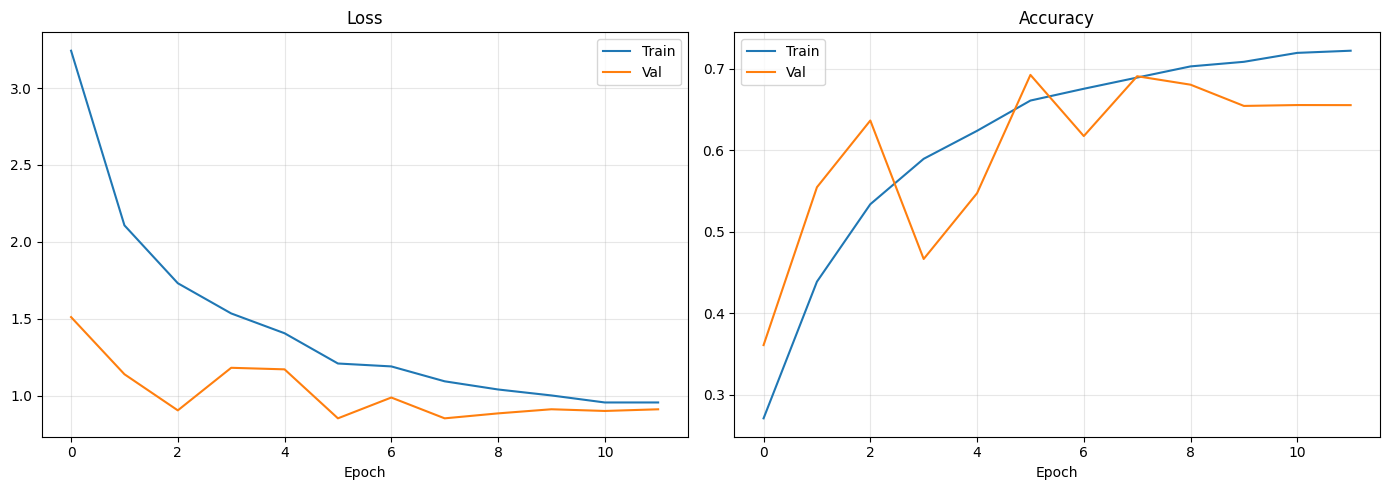

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/training_history.png', dpi=140)
plt.show()

In [74]:
present_classes = sorted(set(y_test) | set(y_pred))
target_names = [label_map[i] for i in present_classes]

report = classification_report(
    y_test,
    y_pred,
    labels=present_classes,
    target_names=target_names,
    digits=4,
    zero_division=0,
)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

per_class_f1_dict = {
    idx: f1_score(y_test, y_pred, labels=[idx], average='macro', zero_division=0)
    for idx in range(6)
}

before_class_table = best_run['before_metrics']['class_table']
after_class_table = best_run['after_metrics']['class_table']

comparison_df = pd.DataFrame([
    {
        'Metric': 'Macro F1',
        'Before': BASELINE_MACRO_F1,
        'After': macro_f1,
        'Delta': macro_f1 - BASELINE_MACRO_F1,
    },
    {
        'Metric': 'None F1',
        'Before': float(before_class_table.loc[before_class_table.class_idx == 0, 'f1'].iloc[0]),
        'After': float(after_class_table.loc[after_class_table.class_idx == 0, 'f1'].iloc[0]),
        'Delta': float(after_class_table.loc[after_class_table.class_idx == 0, 'f1'].iloc[0] - before_class_table.loc[before_class_table.class_idx == 0, 'f1'].iloc[0]),
    },
    {
        'Metric': 'D0 F1',
        'Before': float(before_class_table.loc[before_class_table.class_idx == 1, 'f1'].iloc[0]),
        'After': float(after_class_table.loc[after_class_table.class_idx == 1, 'f1'].iloc[0]),
        'Delta': float(after_class_table.loc[after_class_table.class_idx == 1, 'f1'].iloc[0] - before_class_table.loc[before_class_table.class_idx == 1, 'f1'].iloc[0]),
    },
    {
        'Metric': 'D3 F1',
        'Before': BASELINE_D3_F1,
        'After': per_class_f1_dict[4],
        'Delta': per_class_f1_dict[4] - BASELINE_D3_F1,
    },
    {
        'Metric': 'D4 F1',
        'Before': BASELINE_D4_F1,
        'After': per_class_f1_dict[5],
        'Delta': per_class_f1_dict[5] - BASELINE_D4_F1,
    },
])

gap_last = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
gap_best = best_run['acc_gap_best']

print('=' * 70)
print('CLASSIFICATION REPORT (BEST RUN)')
print('=' * 70)
print(f"Best mode: {best_run['mode']}")
print(f"Thresholds: {best_run['thresholds']}")
print(report)
print('=' * 70)
print(f'Accuracy:    {accuracy:.4f}')
print(f'Macro F1:    {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')
print(f'F1 None:     {per_class_f1_dict[0]:.4f}')
print(f'F1 D0:       {per_class_f1_dict[1]:.4f}')
print(f'F1 D3:       {per_class_f1_dict[4]:.4f}')
print(f'F1 D4:       {per_class_f1_dict[5]:.4f}')
print(f'Train-val gap (last epoch): {gap_last:.4f}')
print(f'Train-val gap (best val_loss epoch): {gap_best:.4f}')
print('=' * 70)

print('\nDominant confusion pairs (before):')
for src, dst, cnt in best_run['dominant_pairs_before']:
    if cnt <= 0:
        continue
    print(f'  {label_map[src]} -> {label_map[dst]}: {cnt}')

print('\nDominant confusion pairs (after):')
for src, dst, cnt in best_run['dominant_pairs_after']:
    if cnt <= 0:
        continue
    print(f'  {label_map[src]} -> {label_map[dst]}: {cnt}')

print('\nRolling-threshold CV diagnostics:')
display(best_run['cv_threshold_diag'])

print('\nPer-class precision/recall/F1 (after):')
display(best_run['class_table'])

print('\nBefore vs After:')
display(comparison_df)

CLASSIFICATION REPORT (BEST RUN)
Best mode: boundary_ce
Thresholds: {0: 1.3, 1: 0.8, 2: 1.3, 4: 0.6, 5: 0.5}
              precision    recall  f1-score   support

        None     0.5670    0.9368    0.7064      4287
          D0     0.5216    0.1068    0.1773      3512
          D1     0.8076    0.7890    0.7982      3298
          D2     0.7671    0.6115    0.6805      1395
          D3     0.5889    0.7649    0.6654       706
          D4     0.7476    0.9767    0.8469       473

    accuracy                         0.6472     13671
   macro avg     0.6666    0.6976    0.6458     13671
weighted avg     0.6412    0.6472    0.5927     13671

Accuracy:    0.6472
Macro F1:    0.6458
Weighted F1: 0.5927
F1 None:     0.7064
F1 D0:       0.1773
F1 D3:       0.6654
F1 D4:       0.8469
Train-val gap (last epoch): 0.1035
Train-val gap (best val_loss epoch): 0.0068

Dominant confusion pairs (before):
  None -> D0: 1465
  D0 -> None: 960
  D0 -> D1: 489
  D2 -> D3: 359
  D2 -> D1: 304
  D1 -> 

,fold,eval_start,eval_end,macro_f1,pair_err_01,pair_err_12,objective
0,1,2021-10-26,2022-02-22,0.700840,0.405626,0.094194,0.629951
1,2,2022-03-01,2022-06-28,0.773693,0.145049,0.083333,0.871212
2,3,2022-07-05,2022-11-01,0.605298,0.478958,0.019231,0.606452
3,4,2022-11-08,2023-03-07,0.711965,0.351351,0.043400,0.757989



Per-class precision/recall/F1 (after):


,class_idx,class_name,precision,recall,f1,support
0,0,None,0.566991,0.936786,0.706420,4287
1,1,D0,0.521558,0.106777,0.177263,3512
2,2,D1,0.807573,0.788963,0.798160,3298
3,3,D2,0.767086,0.611470,0.680495,1395
4,4,D3,0.588877,0.764873,0.665434,706
5,5,D4,0.747573,0.976744,0.846929,473



Before vs After:


,Metric,Before,After,Delta
0,Macro F1,0.590000,0.645784,0.055784
1,None F1,0.694139,0.706420,0.012281
2,D0 F1,0.560350,0.177263,-0.383086
3,D3 F1,0.270000,0.665434,0.395434
4,D4 F1,0.000000,0.846929,0.846929


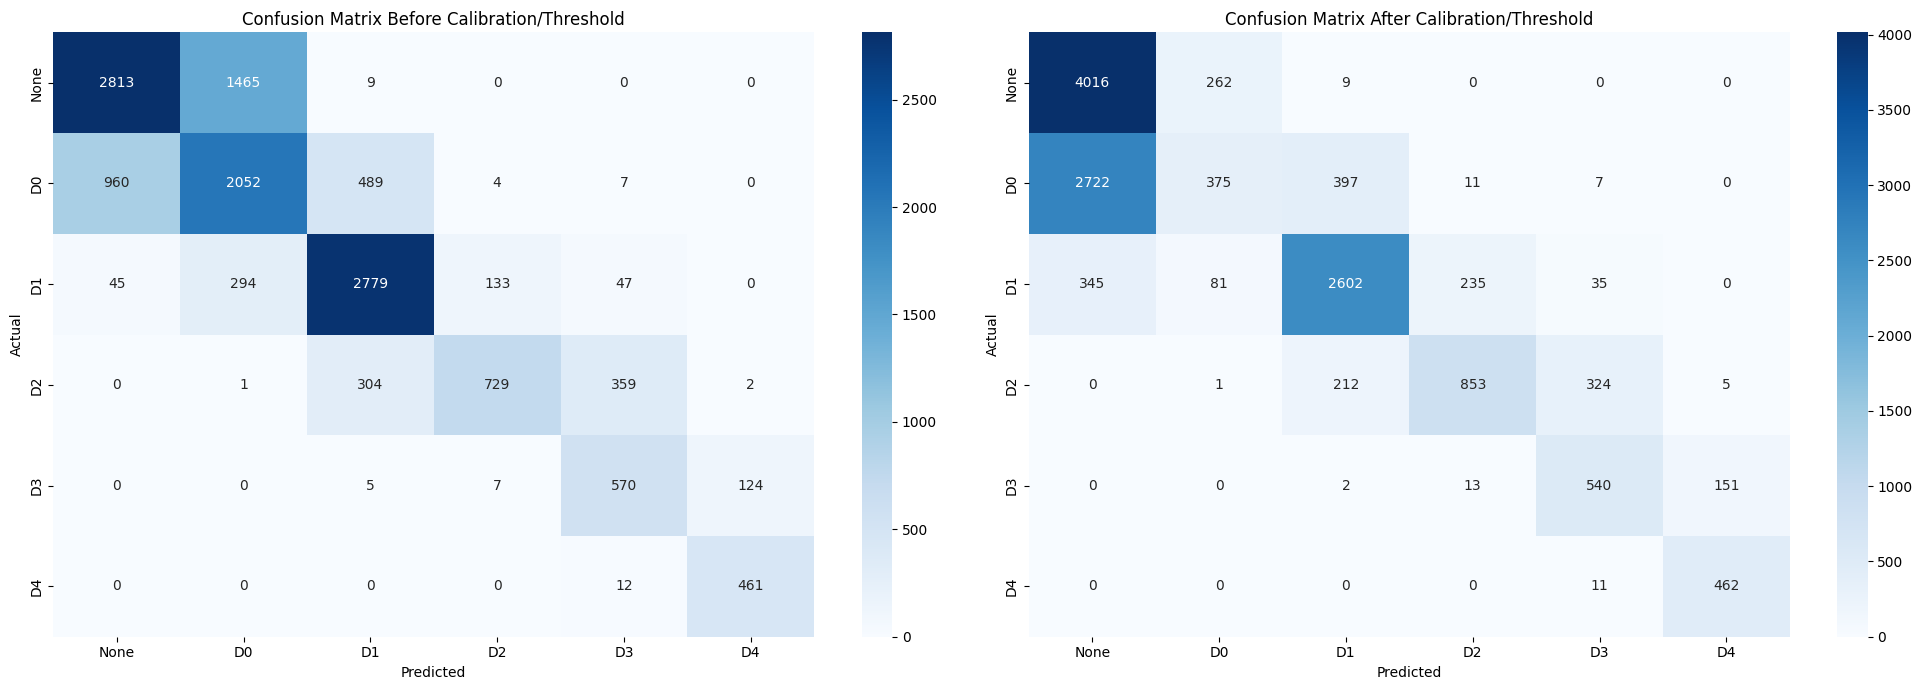

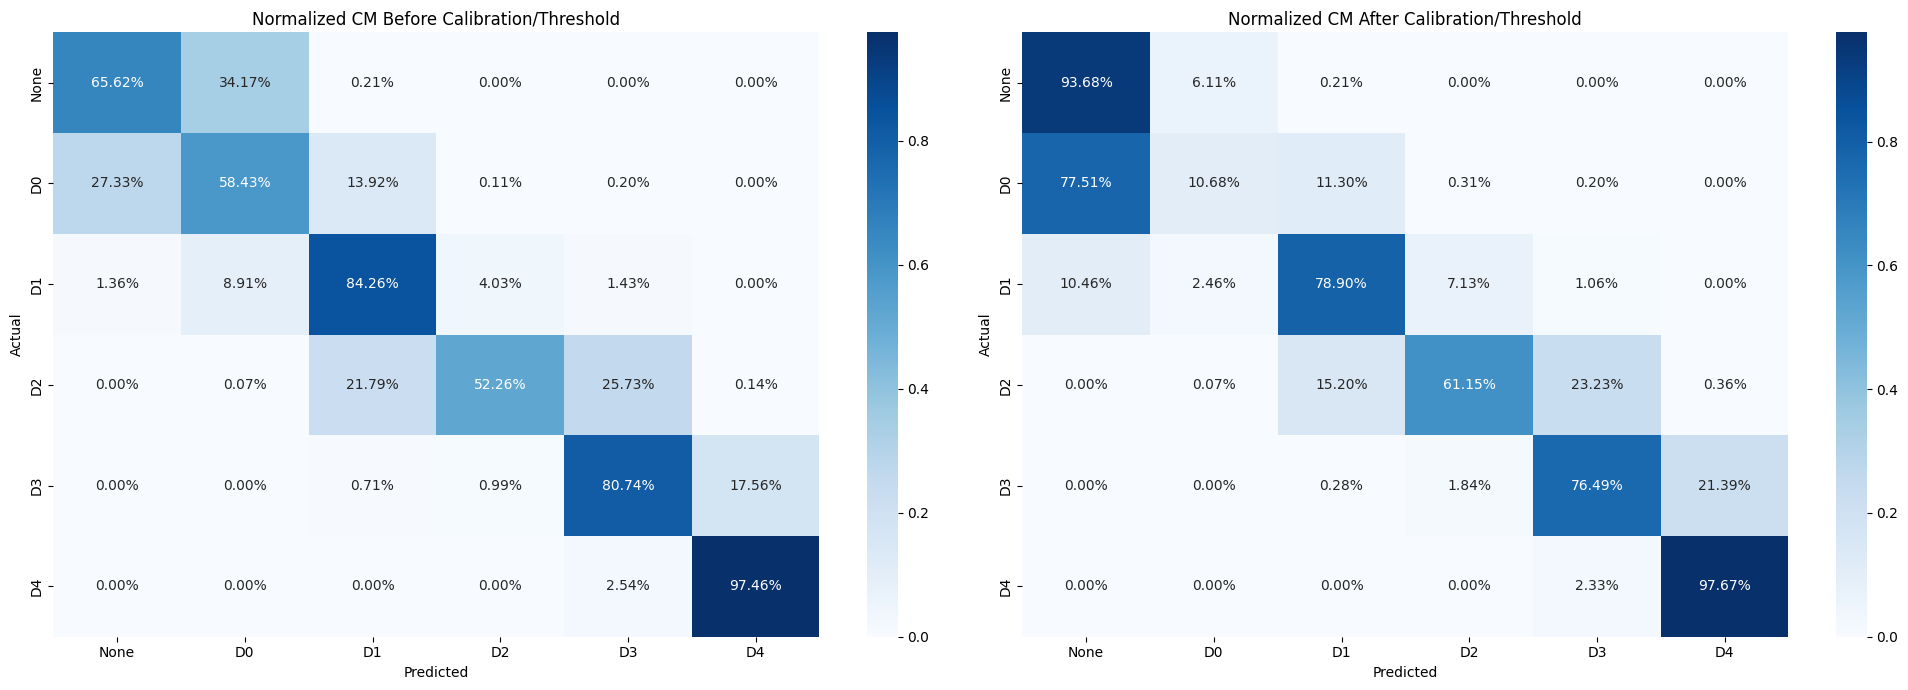

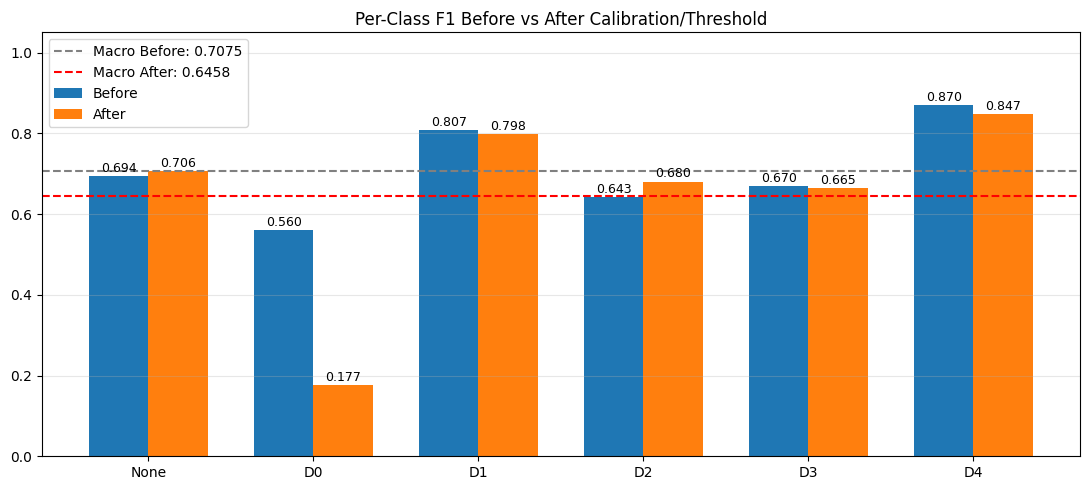

In [77]:
num_classes = 6
labels_idx = list(range(num_classes))

cm_before = best_run['cm_before']
cm_after = best_run['cm_after']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[i] for i in labels_idx],
            yticklabels=[label_map[i] for i in labels_idx],
            ax=axes[0])
axes[0].set_title('Confusion Matrix Before Calibration/Threshold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[i] for i in labels_idx],
            yticklabels=[label_map[i] for i in labels_idx],
            ax=axes[1])
axes[1].set_title('Confusion Matrix After Calibration/Threshold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/confusion_matrix_before_after_counts.png', dpi=140)
plt.show()

cm_before_norm = cm_before.astype(float) / cm_before.sum(axis=1, keepdims=True)
cm_before_norm = np.nan_to_num(cm_before_norm)
cm_after_norm = cm_after.astype(float) / cm_after.sum(axis=1, keepdims=True)
cm_after_norm = np.nan_to_num(cm_after_norm)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(cm_before_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[label_map[i] for i in labels_idx],
            yticklabels=[label_map[i] for i in labels_idx],
            ax=axes[0])
axes[0].set_title('Normalized CM Before Calibration/Threshold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_after_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[label_map[i] for i in labels_idx],
            yticklabels=[label_map[i] for i in labels_idx],
            ax=axes[1])
axes[1].set_title('Normalized CM After Calibration/Threshold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/confusion_matrix_before_after_normalized.png', dpi=140)
plt.show()

per_class_f1_before = best_run['before_metrics']['class_table']['f1'].values
per_class_f1_after = best_run['after_metrics']['class_table']['f1'].values
x = np.arange(num_classes)
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, per_class_f1_before, width=width, label='Before')
ax.bar(x + width / 2, per_class_f1_after, width=width, label='After')

for i, (b, a) in enumerate(zip(per_class_f1_before, per_class_f1_after)):
    ax.text(i - width / 2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)
    ax.text(i + width / 2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([label_map[i] for i in labels_idx])
ax.axhline(best_run['test_macro_raw'], color='gray', linestyle='--', label=f"Macro Before: {best_run['test_macro_raw']:.4f}")
ax.axhline(best_run['test_macro_after'], color='red', linestyle='--', label=f"Macro After: {best_run['test_macro_after']:.4f}")
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 Before vs After Calibration/Threshold')
ax.grid(alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/per_class_f1_before_after.png', dpi=140)
plt.show()

In [78]:
summary_path = f'{OUTPUT_FOLDER}/results_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('BiLSTM Weekly Kansas Clean - Boundary and Calibration Optimization\n')
    f.write(f'Best mode: {best_run["mode"]}\n')
    f.write(f'Selected variant: {best_run["selected_variant"]}\n')
    f.write(f'Thresholds: {best_run["thresholds"]}\n')
    f.write(f'Calibration: {CALIBRATION_METHOD}\n')
    f.write(f'Rolling folds: {ROLLING_FOLDS}\n')
    f.write('Imbalance handling: class_weight only (no ROS)\n')
    f.write(f'Seq Length: {SEQ_LENGTH}\n')
    f.write(f'Accuracy (after): {accuracy:.4f}\n')
    f.write(f'Macro F1 (after): {macro_f1:.4f}\n')
    f.write(f'Weighted F1 (after): {weighted_f1:.4f}\n')
    f.write(f'F1 None (after): {per_class_f1_dict[0]:.4f}\n')
    f.write(f'F1 D0 (after): {per_class_f1_dict[1]:.4f}\n')
    f.write(f'F1 D3 (after): {per_class_f1_dict[4]:.4f}\n')
    f.write(f'F1 D4 (after): {per_class_f1_dict[5]:.4f}\n\n')

    f.write(f'Macro F1 raw argmax: {best_run["test_macro_raw"]:.4f}\n')
    f.write(f'Macro F1 calibrated+thresholded: {best_run["test_macro_calibrated"]:.4f}\n')
    f.write(f'Macro F1 selected final: {best_run["test_macro_after"]:.4f}\n')
    f.write(f'Macro F1 delta (selected final vs raw): {best_run["test_macro_after"] - best_run["test_macro_raw"]:+.4f}\n\n')

    f.write('Before vs After against historical baseline:\n')
    for _, row in comparison_df.iterrows():
        f.write(f"  {row['Metric']}: before={row['Before']:.4f}, after={row['After']:.4f}, delta={row['Delta']:+.4f}\n")

    f.write('\nTop confusion pairs before:\n')
    for src, dst, cnt in best_run['dominant_pairs_before']:
        f.write(f'  {label_map[src]} -> {label_map[dst]}: {cnt}\n')

    f.write('\nTop confusion pairs after:\n')
    for src, dst, cnt in best_run['dominant_pairs_after']:
        f.write(f'  {label_map[src]} -> {label_map[dst]}: {cnt}\n')

    f.write('\nRolling-threshold CV diagnostics:\n')
    if len(best_run['cv_threshold_diag']) == 0:
        f.write('  (no rolling folds available)\n')
    else:
        for _, row in best_run['cv_threshold_diag'].iterrows():
            f.write(
                f"  Fold {int(row['fold'])} ({row['eval_start']} to {row['eval_end']}): "
                f"macro={row['macro_f1']:.4f}, pair01={row['pair_err_01']:.4f}, "
                f"pair12={row['pair_err_12']:.4f}, obj={row['objective']:.4f}\n"
            )

    f.write('\nPer-class F1 (after):\n')
    for i in range(num_classes):
        f.write(f'  {label_map[i]}: {per_class_f1_dict[i]:.4f}\n')

    f.write('\nClassification Report (after):\n')
    f.write(report)

print(f'Results saved to {summary_path}')

Results saved to output_weekly_kansas_clean_expC_recover/results_summary.txt
